In [58]:
import numpy as np
import pandas as pd
import polars as pl
import os
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
import json
from pathlib import Path

## Helpers:

In [ ]:
# Recursively extract all structures
def flatten_structures(node, parent_name=None):
    structures = [{
        'id': node['id'],
        'name': node['name'],
        'acronym': node['acronym'],
        'parent_structure_id': node.get('parent_structure_id'),
        'parent_name': parent_name,
        'graph_order': node.get('graph_order'),
        'st_level': node.get('st_level'),
        'depth': node.get('depth')
    }]
    
    for child in node.get('children', []):
        structures.extend(flatten_structures(child, parent_name=node['name']))
    
    return structures

def get_polygons_from_coords(coords):
    if isinstance(coords[0][0][0], (int, float)):
        # coordinates are not nested, so can be unpacked normally
        return [coords[0]]
    else:
        # coordinates are nested and need to be looped through
        return [coords[0][0]]




## Data Loading:

In [48]:
# ======== 1. Grab Hippocampus data from  json========
PROJ_ROOT = Path.cwd()
ALLEN_STRUCTS = PROJ_ROOT / "data" / "allen_structures.json"

REG_GEO = r"S:\Anshutz\Cruz-Martin_Lab\projects\TBI_Project\QP_test_2\aligned_0.geojson"

pixel_size_um = 0.2125

# --- Extract region ids and names from allen reference json ---
with open(ALLEN_STRUCTS, 'r') as file:
    as_json = json.load(file)

# extract json data and put into flattened list
all_structures = flatten_structures(as_json['msg'][0])

# convert to df for easy filtering
as_df = pl.DataFrame(all_structures)

# Define ROIs by name
target_regions = ['CA1', 'CA2', 'CA3', 'DG-sg', 'DG-mo', 'DG-po', 
                  'ProS', 'SUB']

# look up IDs from allen LUT
hid_list = set(
    as_df.filter(pl.col('acronym').is_in(target_regions))['id'].to_list()
)

# verify what was found
found = as_df.filter(pl.col('id').is_in(hid_list))[['id', 'acronym', 'name']]
print(found)
print(f"\nTotal regions: {len(hid_list)}")


shape: (8, 3)
┌───────────┬─────────┬─────────────────────────────────┐
│ id        ┆ acronym ┆ name                            │
│ ---       ┆ ---     ┆ ---                             │
│ i64       ┆ str     ┆ str                             │
╞═══════════╪═════════╪═════════════════════════════════╡
│ 382       ┆ CA1     ┆ Field CA1                       │
│ 423       ┆ CA2     ┆ Field CA2                       │
│ 463       ┆ CA3     ┆ Field CA3                       │
│ 10703     ┆ DG-mo   ┆ Dentate gyrus, molecular layer  │
│ 10704     ┆ DG-po   ┆ Dentate gyrus, polymorph layer  │
│ 632       ┆ DG-sg   ┆ Dentate gyrus, granule cell la… │
│ 502       ┆ SUB     ┆ Subiculum                       │
│ 484682470 ┆ ProS    ┆ Prosubiculum                    │
└───────────┴─────────┴─────────────────────────────────┘

Total regions: 8


In [49]:
# ======== 2. EXTRACT HIPPOCAMPUS REGIONS FROM GEOJSON ========
with open(REG_GEO, 'r') as file:
    rg_json = json.load(file)

hippo_coords = []
for feature in rg_json['features']:
    try:
        if feature['properties']['name'] != 'Root':
            cur_id = int(float(feature['properties']['measurements']['ID'])) # some larger IDs in scientific notation for some reason - so must convert to float first

            if cur_id in hid_list:

                print(f"cur_id: {cur_id}")

                cur_coords_raw = feature['geometry']['coordinates'] # grab list of all [x,y] coordinate points for the current region
                
                # unpack the coordinates into a standard list
                polygon_list = get_polygons_from_coords(cur_coords_raw)

                for polygon in polygon_list:
                    print(f"poly list: {polygon_list}")
                    cur_coords_um = np.array(polygon)[:, :2] * pixel_size_um
                    hippo_coords.append(cur_coords_um)
                    

                # translate the ABBA coordinates into the same coordinate space as the Xenium transcsripts use:
                #cur_coords_um = [[coord[0] * pixel_size_um, coord[1] * pixel_size_um] for coord in cur_coords]

                #hippo_coords.append(np.array(cur_coords_um))

    except (ValueError, KeyError) as e:
        print(f"WARNING - Failed to get Object ID from: {feature['properties']}")
        print(f"  Error: {e}")
        
print(f"Extracted {len(hippo_coords)} relevant hippocampus coordinate regions")


cur_id: 632
poly list: [[[21496.77, 17850.27], [21438.51, 17858.16], [21423.86, 17860.73], [21365.1, 17871.07], [21350.36, 17873.75], [21291.03, 17885.89], [21278.26, 17890.23], [21181.84, 17939.29], [21171.21, 17945.86], [21075.52, 18012.57], [21064.79, 18020.53], [20966.99, 18094.33], [20953.84, 18103.06], [20891.9, 18138.83], [20879.93, 18147.7], [20741.27, 18273.01], [20731.22, 18281.67], [20628.62, 18365.11], [20617.21, 18374.43], [20514.78, 18458.84], [20503.44, 18468.27], [20401.83, 18553.64], [20391.9, 18562.58], [20254.78, 18694.21], [20245.05, 18703.15], [20147.13, 18788.46], [20136.37, 18797.88], [20040.57, 18882.07], [20030.05, 18891.35], [19936.43, 18974.16], [19927.33, 18982.73], [19802.48, 19107.03], [19793.66, 19115.22], [19704.82, 19190.6], [19695.04, 19198.67], [19607.72, 19268.41], [19599.21, 19275.52], [19481.68, 19376.15], [19474.38, 19382.05], [19358.14, 19469.94], [19349.8, 19475.29], [19264.73, 19522.63], [19256.4, 19527.79], [19140.99, 19611.22], [19134.5, 1961

In [50]:
region_counts = {}
for feature in rg_json['features']:
    try:
        cur_id = int(float(feature['properties']['measurements']['ID']))
        if cur_id in hid_list:
            name = feature['properties']['name']
            coords = feature['geometry']['coordinates']
            n_polygons = len(get_polygons_from_coords(coords))
            region_counts[name] = {'id': cur_id, 'n_polygons': n_polygons}
    except:
        pass

for name, info in region_counts.items():
    print(f"{name} (ID: {info['id']}): {info['n_polygons']} polygon(s)")
print(f"\nTotal unique regions: {len(region_counts)}")

DG-sg (ID: 632): 1 polygon(s)
DG-mo (ID: 10703): 1 polygon(s)
DG-po (ID: 10704): 1 polygon(s)
CA1 (ID: 382): 1 polygon(s)
CA2 (ID: 423): 1 polygon(s)
CA3 (ID: 463): 1 polygon(s)
ProS (ID: 484682470): 1 polygon(s)
SUB (ID: 502): 1 polygon(s)

Total unique regions: 8


In [51]:
# ======== 3. LOAD TRANSCRIPT ========
#transcripts_path = r"S:\Anshutz\Cruz-Martin_Lab\projects\TBI_Project\data\Yaseer_Example\InputTranscripts.tsv"
transcripts_path = r"S:\Anshutz\Cruz-Martin_Lab\projects\TBI_Project\data\20251013_FT_24hrs_Sag9_ID57476\Transcripts\transcripts.parquet"

# Lazy loading approach w/ box filter around region of interest:
scanner = pl.scan_parquet(transcripts_path)

# grab the length of the parquet from the metadata & return
full_count = scanner.select(pl.len()).collect().item()
print(f"Total transcripts in parquet: {full_count:,}")

# vertically stack all the geoJson coordinate sets into a single np array for easy operations
stacked_coords = np.vstack(hippo_coords)

# grab all of the min & max coordinates for x & y
min_x = stacked_coords[:, 0].min()
max_x = stacked_coords[:, 0].max()
min_y = stacked_coords[:, 1].min()
max_y = stacked_coords[:, 1].max()

# load transcripts to df that are inside hippocampus box and format for punst tsv
print("Attempting to load transcript parquet file...")
hip_box_df = scanner.select(
    # select these columns with simplified column names:
    pl.col("x_location").alias("x").cast(pl.Float32),
    pl.col("y_location").alias("y").cast(pl.Float32),
    pl.col("feature_name").alias("gene").cast(pl.Categorical),
    pl.lit(1).cast(pl.Int16).alias("count") # set the count column to 1 on every row
).filter(
    # only grab rows that are within a box formed by the min and max hippo coordinates
    (pl.col("x") >= min_x) & (pl.col("x") <= max_x) &
    (pl.col("y") >= min_y) & (pl.col("y") <= max_y)
).collect() # load only the regions within our box into the dataframe

print(f"Hippo Box dataframe: {hip_box_df.estimated_size() / 1e9:.2f} GB")

Total transcripts in parquet: 328,443,152
Attempting to load transcript parquet file...
Hippo Box dataframe: 0.29 GB


In [53]:
# ======== 4. CROP TRANSCRIPT ========
full_mask = np.zeros(len(hip_box_df), dtype=bool)

# extract the coordinates into a np array for use in matplot masking
print("Converting coordinates to np array...")
t_coords_np = hip_box_df[["x", "y"]].to_numpy()

for i, region in enumerate(hippo_coords): # for each sub region contained in our full set of hippo coordinates
    print(f"\rChecking Hippocampus region: {i + 1}/{len(hippo_coords)}", end="", flush=True)

    # Pre-filter points within this polygon's bounding box
    min_x, min_y = region[:, 0].min(), region[:, 1].min()
    max_x, max_y = region[:, 0].max(), region[:, 1].max()

    bbox_mask = (
        (t_coords_np[:, 0] >= min_x) & (t_coords_np[:, 0] <= max_x) &
        (t_coords_np[:, 1] >= min_y) & (t_coords_np[:, 1] <= max_y)
    )
    bbox_indices = np.where(bbox_mask)[0]

    # create a matplot path object using the current region coordinates
    path = MplPath(region) 

    # create a boolean array of len(hip_box_df), where it is True whenever a coordinate point falls inside the current region
    mask = path.contains_points(t_coords_np[bbox_indices]) 

     # combine masks using an or operation, so that if a coordinate is in any region, it will be saved
    full_mask[bbox_indices[mask]] = True

# save only the transcripts inside the full hippo mask
cropped_transcripts = hip_box_df.filter(full_mask)

# output the cropped df to a csv
cropped_transcripts.write_csv("cropped_transcripts.tsv", separator="\t")

print(f"\nCropped transcripts: {len(cropped_transcripts):,} / {full_count:,}")

Converting coordinates to np array...
Checking Hippocampus region: 1/8

Checking Hippocampus region: 8/8
Cropped transcripts: 13,560,958 / 328,443,152


In [54]:
# ======== 5. CALCULATE ACCURATE AREA ========
def polygon_area(x, y):
    """Shoelace formula for polygon area"""
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

# Use the original polygon (before closing)
if polygon.shape[0] > 2:  # Ensure it's a valid polygon
    area = polygon_area(polygon[:-1, 0], polygon[:-1, 1])
    print(f"\nROI area (polygon): {area:,.2f} units²")
else:
    print("Warning: Invalid polygon for area calculation")


AttributeError: 'list' object has no attribute 'shape'

In [ ]:
# ======== 6. ANALYSIS ========
print("=== BASIC STATS ===")
print(f"Total transcripts: {len(cropped_transcripts):,}")
print(f"Unique genes: {cropped_transcripts['gene'].n_unique():,}")

=== BASIC STATS ===
Total transcripts: 13,560,958
Unique genes: 13,761


In [ ]:
# Transcript density (if area is valid)
if 'area' in locals() and area > 0:
    density = len(cropped_transcripts) / area
    print(f"Transcript density: {density:.2f} transcripts/unit²")

In [ ]:
# Top genes
top_genes = (
    cropped_transcripts
    .group_by("gene")
    .agg(pl.col("count").sum())
    .sort("count", descending=True)
    .head(20)
)
print("\nTop 20 genes:")
for g, c in top_genes.rows():
    print(f"  {g}: {c:,}")


Top 20 genes:
  Camk2a: 331,013
  Aldoa: 120,237
  Map2: 115,088
  Snap25: 97,893
  Camk2b: 93,504
  Ndrg2: 91,070
  Ckb: 84,680
  Aldoc: 83,179
  Nsmf: 74,602
  Cyfip2: 69,714
  Slc1a3: 65,395
  Vamp2: 63,700
  Map1b: 60,186
  Gnao1: 59,917
  Dnm1: 59,458
  Kif5a: 57,066
  Ywhag: 56,226
  Eno2: 54,556
  Kcnab2: 52,953
  Gabbr1: 51,361


In [ ]:
# ======== 7. SAVE RESULTS ========
output_dir = r""
os.makedirs(output_dir, exist_ok=True)

# Save cropped transcripts
output_path = os.path.join(output_dir, "20251125_MT_48hrs_MH2_Sag18_ID58144croppedhippo.tsv")
cropped_transcripts.to_csv(output_path, sep="\t", index=False)

# Save polygon
polygon_df = pd.DataFrame(polygon, columns=["x", "y"])
polygon_path_out = os.path.join(output_dir, "20251125_MT_48hrs_MH2_Sag18_ID58144croppedpolygon.tsv")
polygon_df.to_csv(polygon_path_out, sep="\t", index=False)

print(f"\nSaved outputs to: {output_dir}")
print(f"  - Cropped transcripts: {output_path}")
print(f"  - Polygon coordinates: {polygon_path_out}")


Saved outputs to: C:\Users\yasee\OneDrive\Documents
  - Cropped transcripts: C:\Users\yasee\OneDrive\Documents\20251125_MT_48hrs_MH2_Sag18_ID58144croppedhippo.tsv
  - Polygon coordinates: C:\Users\yasee\OneDrive\Documents\20251125_MT_48hrs_MH2_Sag18_ID58144croppedpolygon.tsv


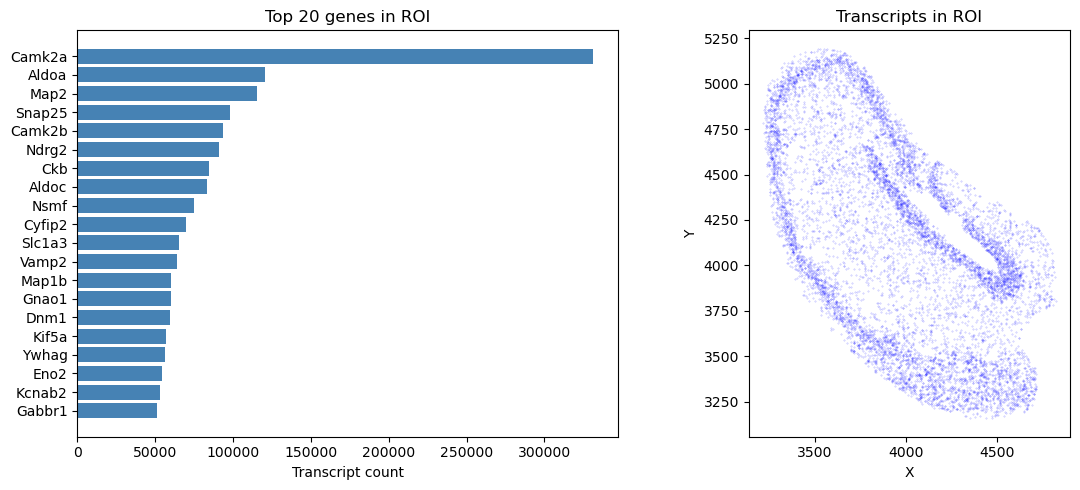

In [ ]:
# ======== 8. VISUALIZATION ========
if len(top_genes) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Top genes
    axes[0].barh(top_genes["gene"], top_genes["count"], color="steelblue")
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Transcript count")
    axes[0].set_title("Top 20 genes in ROI")
    
    # Plot 2: Spatial distribution (sample)
    sample_cropped = cropped_transcripts.sample(n=min(10000, len(cropped_transcripts)))
    axes[1].scatter(sample_cropped["x"], sample_cropped["y"], s=0.1, alpha=0.3, c='blue')
    #axes[1].plot(polygon[:, 0], polygon[:, 1], 'r-', linewidth=2)
    axes[1].set_aspect('equal')
    axes[1].set_title("Transcripts in ROI")
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")
    
    plt.tight_layout()
    plt.show()

# DEBUGGING - REMOVE WHEN DONE

In [56]:
for feature in rg_json['features']:
    try:
        cur_id = int(float(feature['properties']['measurements']['ID']))
        if cur_id in hid_list:
            coords = np.array(feature['geometry']['coordinates'][0]) * pixel_size_um
            x_range = coords[:, 0].max() - coords[:, 0].min()
            y_range = coords[:, 1].max() - coords[:, 1].min()
            print(f"{feature['properties']['name']} (ID: {cur_id}) | X range: {x_range:.0f}μm | Y range: {y_range:.0f}μm")
    except:
        pass

DG-sg (ID: 632) | X range: 775μm | Y range: 761μm
DG-mo (ID: 10703) | X range: 872μm | Y range: 871μm
DG-po (ID: 10704) | X range: 465μm | Y range: 468μm
CA1 (ID: 382) | X range: 771μm | Y range: 726μm
CA2 (ID: 423) | X range: 976μm | Y range: 994μm
CA3 (ID: 463) | X range: 255μm | Y range: 258μm
ProS (ID: 484682470) | X range: 418μm | Y range: 516μm
SUB (ID: 502) | X range: 541μm | Y range: 494μm


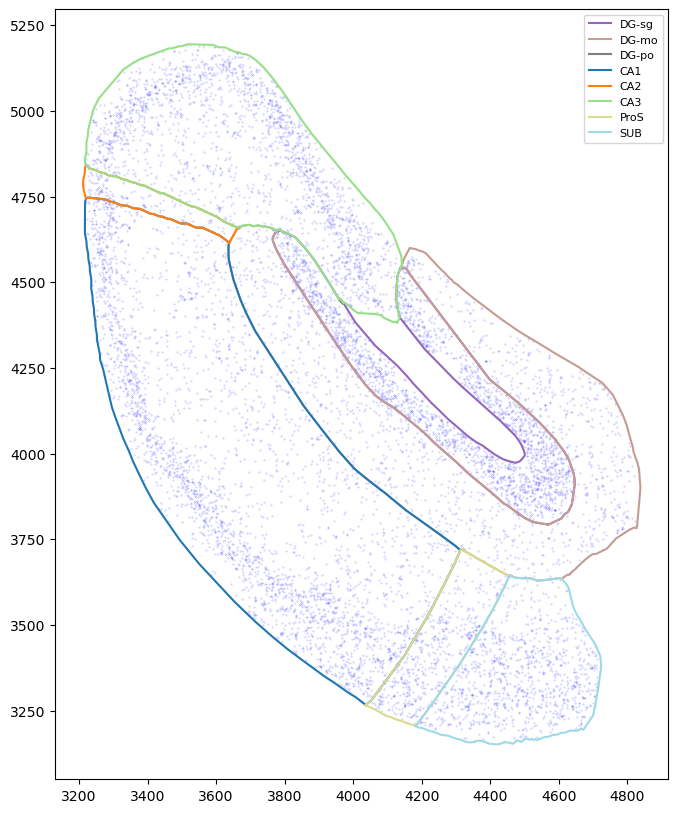

In [57]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(sample_cropped["x"], sample_cropped["y"], s=0.1, alpha=0.3, c='blue')

# Color polygons by region
region_colors = plt.cm.tab20(np.linspace(0, 1, len(target_regions)))
region_color_map = dict(zip(target_regions, region_colors))

# loop through all of the features in the geojson
for feature in rg_json['features']:
    try:
        cur_id = int(float(feature['properties']['measurements']['ID']))

        # if the current node matches one of the chosen hippocamus IDs
        if cur_id in hid_list:
            name = feature['properties']['name']

            # unpack the coordinate list 
            polygon_list = get_polygons_from_coords(feature['geometry']['coordinates'])
            
            # loop through all potential sub-polygons from the coordinate region
            for polygon in polygon_list:

                # convert to um space
                coords_um = np.array(polygon)[:, :2] * pixel_size_um

                # plot the current polygon outline 
                ax.plot(coords_um[:, 0], coords_um[:, 1], '-',
                       linewidth=1.5, 
                       color=region_color_map.get(name, 'red'),
                       label=name)
    except:
        pass

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8)

ax.set_aspect('equal')
plt.show()